In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from ast import literal_eval
from collections import defaultdict

from scipy import stats
from scipy.stats import mannwhitneyu, fisher_exact, false_discovery_control
from scipy import stats
import pickle

In [2]:
adata = sc.read_h5ad("/rds/general/user/ao225/home/CardiaFinal/Data/Post_Processed/Science/NewCardiac.h5ad")

In [3]:
with open("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/SCENIC_results/lv_regulons.dat", "rb") as f:
    regulon_objs = pickle.load(f)

regulons = {r.name: set(r.genes) for r in regulon_objs}
ens2sym = adata.var["feature_name"].astype(str).to_dict()

print("regulons:", len(regulons))

/rds/general/user/ao225/home/miniforge3/envs/ml_age/lib/python3.9/site-packages/ctxcore/__init__.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


regulons: 72


In [4]:
# --- donor-level regulon activity: DCM vs control ---
auc_df = pd.DataFrame(adata.obsm["AUCell"], columns=adata.uns["regulons"], index=adata.obs_names)

pb = auc_df.groupby([adata.obs["donor_id"].values, adata.obs["disease"].values],
                    observed=True).mean()
pb.index.names = ["donor", "disease"]
print(pb.shape)
print(pb.index.get_level_values("disease").value_counts())   # 38 DCM, 12 normal

dcm = pb.xs("dilated cardiomyopathy", level="disease")
nor = pb.xs("normal", level="disease")

res = [mannwhitneyu(dcm[c], nor[c], alternative="two-sided") for c in pb.columns]
u = [r.statistic for r in res]
p = [r.pvalue for r in res]

out = pd.DataFrame({
    "regulon":     pb.columns,
    "mean_DCM":    dcm.mean(0).values,
    "mean_normal": nor.mean(0).values,
    "delta_AUC":   (dcm.mean(0) - nor.mean(0)).values,
    "pct_change":  (100 * (dcm.mean(0) - nor.mean(0)) / nor.mean(0)).values,
    "U": u, "pval": p,
})

out["padj"]        = stats.false_discovery_control(out["pval"])
out                = out.sort_values("padj")
out["significant"] = out["padj"] < 0.05
out["n_targets"]   = out["regulon"].map(lambda t: len(regulons.get(t, set())))

out.to_csv("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/Table/Supplementary_regulon_activity.csv",
           index=False)

print(out.head(20).to_string(index=False))
print("significant:", out["significant"].sum(), "of", len(out))

(50, 72)
disease
dilated cardiomyopathy    38
normal                    12
Name: count, dtype: int64
regulon  mean_DCM  mean_normal  delta_AUC  pct_change     U     pval     padj  significant  n_targets
ZNF518A  0.100160     0.086050   0.014110   16.397534 414.0 0.000025 0.000904         True         73
 ZNF431  0.034085     0.044351  -0.010265  -23.145862  41.0 0.000023 0.000904         True         26
  ZNF43  0.042559     0.058504  -0.015945  -27.255057  53.0 0.000074 0.000973         True         15
  IKZF2  0.182477     0.167256   0.015221    9.100462 402.0 0.000081 0.000973         True         46
 ZBTB16  0.352644     0.245693   0.106951   43.530217 405.0 0.000061 0.000973         True         10
  FOXO1  0.109664     0.092825   0.016838   18.139751 406.0 0.000055 0.000973         True        364
   KLF9  0.164540     0.130204   0.034336   26.371019 393.0 0.000186 0.001918         True         78
  FOXO3  0.129212     0.111546   0.017666   15.837608 382.0 0.000489 0.004167      

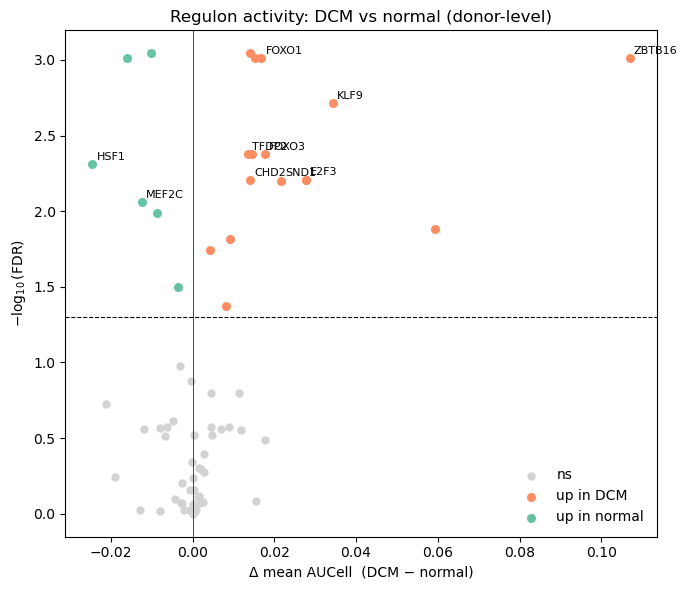

In [5]:
# --- volcano: regulon activity ---
out["neglog10_padj"] = -np.log10(out["padj"])
sig = out["padj"] < 0.05

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(out.loc[~sig, "delta_AUC"], out.loc[~sig, "neglog10_padj"],
           c="lightgray", s=25, label="ns")
ax.scatter(out.loc[sig & (out.delta_AUC > 0), "delta_AUC"],
           out.loc[sig & (out.delta_AUC > 0), "neglog10_padj"],
           c="#FC8D62", s=30, label="up in DCM")
ax.scatter(out.loc[sig & (out.delta_AUC < 0), "delta_AUC"],
           out.loc[sig & (out.delta_AUC < 0), "neglog10_padj"],
           c="#66C2A5", s=30, label="up in normal")

label_these = ["KLF9","FOXO1","FOXO3","MEF2C","TFDP2","CHD2","SND1","HSF1","ZBTB16","E2F3"]
for _, r in out[out.regulon.isin(label_these)].iterrows():
    ax.annotate(r["regulon"], (r["delta_AUC"], r["neglog10_padj"]),
                fontsize=8, xytext=(3, 3), textcoords="offset points")

ax.axhline(-np.log10(0.05), ls="--", c="k", lw=0.8)
ax.axvline(0, ls="-", c="k", lw=0.5)
ax.set_xlabel("Δ mean AUCell  (DCM − normal)")
ax.set_ylabel(r"$-\log_{10}$(FDR)")
ax.set_title("Regulon activity: DCM vs normal (donor-level)")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/plots/volcano_regulons_DCM_vs_normal.png", dpi=300)
plt.show()

In [14]:
# --- Fisher: are DCM-specific ds genes over-represented among regulon targets? ---
gene_set = "/rds/general/user/ao225/home/CardiaFinal/Results/ROGUE/gene_set"

# ds gene sets per group, mapped to symbols
ds = {}
for g in ["control", "chromatin", "sarcomere", "splicing", "PVneg"]:
    ens = pd.read_csv(f"{gene_set}/ds_{g}.txt", header=None)[0].astype(str).tolist()
    ds[g] = {ens2sym.get(e) for e in ens} - {None}
    print(g, len(ens), "->", len(ds[g]), "symbols")

# DCM-specific: significant in any DCM genotype, not in control
dcm_ds = (ds["chromatin"] | ds["sarcomere"] | ds["splicing"] | ds["PVneg"]) - ds["control"]
print("DCM-specific ds genes:", len(dcm_ds))

# universe = all SE_fun-tested genes, as symbols
refset_ens = pd.read_csv(f"{gene_set}/refset.txt", header=None)[0].astype(str).tolist()
universe = {ens2sym.get(e) for e in refset_ens} - {None}
print("universe size:", len(universe))

dcm_ds &= universe
N, K = len(universe), len(dcm_ds)

sig_regs = out.loc[out["padj"] < 0.05, "regulon"].tolist()

rows = []
for tf in sig_regs:
    targ = regulons.get(tf, set()) & universe          # only testable targets
    if len(targ) < 5:
        continue
    a = len(targ & dcm_ds); b = len(targ) - a
    c = K - a;              d = N - len(targ) - c
    odds, p = fisher_exact([[a, b], [c, d]], alternative="greater")
    rows.append({"regulon": tf, "n_targets": len(targ), "targets_ds": a,
                 "expected": round(len(targ) * K / N, 1),
                 "odds_ratio": round(odds, 2), "pval": p})

val = pd.DataFrame(rows)
val["padj"] = false_discovery_control(val["pval"])
val = val.merge(out[["regulon", "delta_AUC", "pct_change"]], on="regulon").sort_values("pval")
val["interpretable"] = val["n_targets"] >= 50

val.to_csv("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/Table/Supplementary_regulon_entropy_enrichment.csv",
           index=False)
print(val.to_string(index=False))

control 143 -> 143 symbols
chromatin 243 -> 243 symbols
sarcomere 197 -> 197 symbols
splicing 171 -> 171 symbols
PVneg 193 -> 193 symbols
DCM-specific ds genes: 217
universe size: 20606
regulon  n_targets  targets_ds  expected  odds_ratio         pval         padj  delta_AUC  pct_change  interpretable
   KLF9         78          15       0.8       23.96 3.248084e-15 7.145784e-14   0.034336   26.371019           True
  FOXO1        364          21       3.8        6.26 3.128798e-10 3.441678e-09   0.016838   18.139751           True
 ZNF407        648          27       6.8        4.52 1.204120e-09 8.830212e-09   0.008146    6.402790           True
  TFDP2        597          25       6.3        4.51 4.703083e-09 2.586696e-08   0.013579   11.124215           True
  FOXO3        208          14       2.2        7.18 4.675140e-08 2.057062e-07   0.017666   15.837608           True
 ZBTB16         10           4       0.1       63.80 2.390625e-06 8.765624e-06   0.106951   43.530217          F

In [7]:
mapped = [ens2sym.get(e) for e in refset_ens]
print("unmapped:", sum(v is None for v in mapped))
print("duplicate symbols:", len(mapped) - len(set(mapped)))

unmapped: 0
duplicate symbols: 2


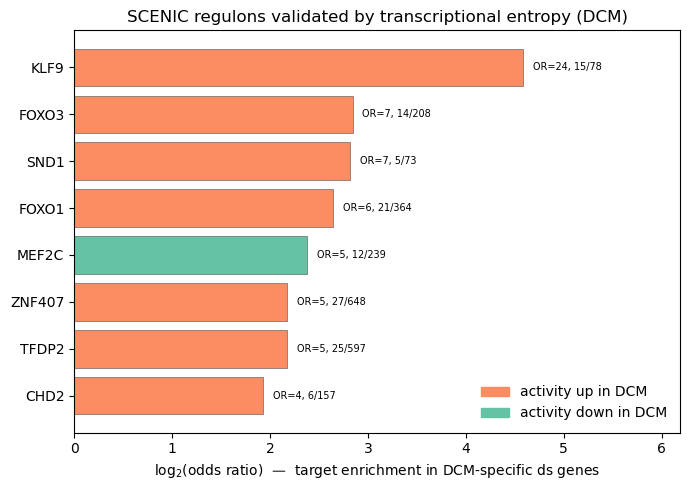

In [9]:
# --- bar chart: regulons validated by transcriptional entropy ---
v = val[(val["padj"] < 0.05) & (val["interpretable"])].copy().sort_values("odds_ratio")
colors = np.where(v["delta_AUC"] > 0, "#FC8D62", "#66C2A5")

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(v["regulon"], np.log2(v["odds_ratio"]), color=colors,
        edgecolor="0.3", linewidth=.4)

for y, (_, r) in enumerate(v.iterrows()):
    ax.text(np.log2(r["odds_ratio"]) + 0.1, y,
            f"OR={r['odds_ratio']:.0f}, {r['targets_ds']}/{r['n_targets']}",
            va="center", fontsize=7)

ax.set_xlim(0, np.log2(v["odds_ratio"].max()) * 1.35)
ax.set_xlabel("log$_2$(odds ratio)  —  target enrichment in DCM-specific ds genes")
ax.set_title("SCENIC regulons validated by transcriptional entropy (DCM)")
ax.legend(handles=[Patch(color="#FC8D62", label="activity up in DCM"),
                   Patch(color="#66C2A5", label="activity down in DCM")],
          frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/plots/regulon_entropy_validation.png", dpi=300)
plt.show()

In [15]:
# --- Δds: do a regulon's targets show greater entropy expansion than the rest? ---
ent_dir    = "/rds/general/user/ao225/home/CardiaFinal/Results/ROGUE/per_gene"
dcm_groups = ["chromatin", "sarcomere", "splicing", "PVneg"]
load = lambda g: pd.read_csv(f"{ent_dir}/ds_{g}.csv").set_index("Gene")["ds"]

# Δds = mean ds across DCM genotypes − control ds
dcm_mean = pd.concat([load(g) for g in dcm_groups], axis=1).mean(axis=1)   # ignores NaN
ctrl     = load("control")
delta    = (dcm_mean - ctrl).dropna()

# ENSG -> symbol, collapse duplicates
delta.index = delta.index.map(lambda e: ens2sym.get(e))
delta = delta[delta.index.notna()].groupby(level=0).mean()
universe_dds = set(delta.index)
print("genes with Δds:", len(universe_dds))

rows = []
for tf in sig_regs:
    targ = regulons.get(tf, set()) & universe_dds
    if len(targ) < 5:
        continue
    inn = delta[delta.index.isin(targ)]
    bg  = delta[~delta.index.isin(targ)]
    U, p = mannwhitneyu(inn, bg, alternative="greater")
    rows.append({"regulon": tf, "n_targets": len(targ),
                 "median_dds_target": round(inn.median(), 5),
                 "median_dds_bg": round(bg.median(), 5),
                 "U": U, "pval": p})

r = pd.DataFrame(rows)
r["padj"] = false_discovery_control(r["pval"])
r = r.merge(out[["regulon", "delta_AUC", "pct_change"]], on="regulon").sort_values("pval")
r["interpretable"] = r["n_targets"] >= 50

r.to_csv("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/Table/Supplementary_regulon_delta_ds.csv",
         index=False)
print(r.to_string(index=False))

genes with Δds: 19304
regulon  n_targets  median_dds_target  median_dds_bg         U         pval         padj  delta_AUC  pct_change  interpretable
 ZNF407        648            0.00077       -0.00004 7222662.0 1.483244e-17 3.263138e-16   0.008146    6.402790           True
  FOXO1        364            0.00073       -0.00003 4175915.0 2.248619e-12 2.473481e-11   0.016838   18.139751           True
   KLF9         78            0.00342       -0.00003 1020465.0 1.791431e-08 1.313716e-07   0.034336   26.371019           True
  MEF2C        239            0.00078       -0.00003 2680292.0 1.329179e-06 7.310485e-06  -0.012399   -8.477131           True
  FOXO3        208            0.00055       -0.00003 2349009.0 2.794229e-06 1.229461e-05   0.017666   15.837608           True
   NFIB         21            0.00386       -0.00003  308153.0 1.732539e-05 6.352644e-05   0.014570   10.885075          False
 ZBTB16         10            0.01079       -0.00003  162314.0 9.300496e-05 2.923013e-04 

In [12]:
# --- per-genotype validation: Fisher + Δds within each DCM genotype ---
ctrl_ds = load("control")
N = len(universe)

fisher_rows, dds_rows = [], []
for g in dcm_groups:
    # (a) Fisher: this genotype's ds genes, excluding those also ds in control
    hs = ds[g] - ds["control"]
    K  = len(hs)
    for tf in sig_regs:
        targ = regulons.get(tf, set()) & universe
        if len(targ) < 5: continue
        a = len(targ & hs); b = len(targ) - a; c = K - a; d = N - len(targ) - c
        odds, p = fisher_exact([[a, b], [c, d]], alternative="greater")
        fisher_rows.append({"regulon": tf, "group": g, "OR": round(odds, 1), "pval": p})

    # (b) Δds: this genotype minus control
    dlt = (load(g) - ctrl_ds).dropna()
    dlt.index = dlt.index.map(lambda e: ens2sym.get(e))
    dlt = dlt[dlt.index.notna()].groupby(level=0).mean()
    uni = set(dlt.index)
    for tf in sig_regs:
        targ = regulons.get(tf, set()) & uni
        if len(targ) < 5: continue
        inn = dlt[dlt.index.isin(targ)]; bg = dlt[~dlt.index.isin(targ)]
        U, p = mannwhitneyu(inn, bg, alternative="greater")
        dds_rows.append({"regulon": tf, "group": g,
                         "med_dds": round(inn.median(), 4), "pval": p})

fis = pd.DataFrame(fisher_rows); fis["padj"] = fis.groupby("group")["pval"].transform(false_discovery_control)
dds = pd.DataFrame(dds_rows);    dds["padj"] = dds.groupby("group")["pval"].transform(false_discovery_control)

# validated = passes BOTH tests in that genotype
pass_f = {(x.regulon, x.group) for x in fis.itertuples() if x.padj < 0.05}
pass_d = {(x.regulon, x.group) for x in dds.itertuples() if x.padj < 0.05}
both   = pass_f & pass_d

mat = pd.DataFrame(0, index=sorted({tf for tf, _ in both}), columns=dcm_groups)
for tf, g in both:
    mat.loc[tf, g] = 1
mat["n_genotypes"]   = mat[dcm_groups].sum(axis=1)
mat["n_targets"]     = [len(regulons.get(tf, set()) & universe) for tf in mat.index]
mat["interpretable"] = mat["n_targets"] >= 50

mat = mat.sort_values(["n_genotypes", "n_targets"], ascending=False)
mat.to_csv("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/Table/Supplementary_regulon_genotype_validation.csv")
print(mat.to_string())

        chromatin  sarcomere  splicing  PVneg  n_genotypes  n_targets  interpretable
FOXO1           1          1         1      1            4        364           True
FOXO3           1          1         1      1            4        208           True
KLF9            1          1         1      1            4         78           True
ZNF407          1          0         1      1            3        648           True
MEF2C           1          0         1      1            3        239           True
ZNF189          1          1         0      1            3         22          False
ZBTB16          1          1         0      0            2         10          False
TFDP2           0          0         0      1            1        597           True
CHD2            1          0         0      0            1        157           True
NFIB            1          0         0      0            1         21          False


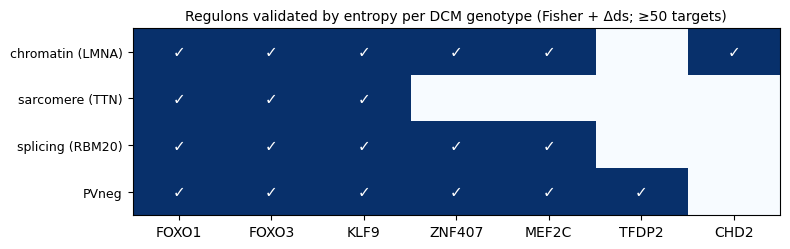

In [13]:
# --- heatmap: regulons validated per DCM genotype ---
m_full = mat[mat["interpretable"]]
m = m_full[dcm_groups].T

fig, ax = plt.subplots(figsize=(8, 2.6))
ax.imshow(m.values, cmap="Blues", vmin=0, vmax=1, aspect="auto", interpolation="nearest")

ax.set_xticks(range(len(m.columns)))
ax.set_xticklabels(m.columns, fontsize=10)
ax.set_yticks(range(len(dcm_groups)))
ax.set_yticklabels(["chromatin (LMNA)", "sarcomere (TTN)", "splicing (RBM20)", "PVneg"], fontsize=9)

for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        if m.values[i, j]:
            ax.text(j, i, "✓", ha="center", va="center", color="white", fontsize=11)

ax.set_title("Regulons validated by entropy per DCM genotype (Fisher + Δds; ≥50 targets)", fontsize=10)

plt.tight_layout()
plt.savefig("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/plots/regulon_validation_by_genotype.png", dpi=300)
plt.show()

In [27]:
adata.obs.columns

Index(['Sample', 'donor_id', 'Region_x', 'Primary.Genetic.Diagnosis',
       'n_genes', 'n_counts', 'percent_mito', 'percent_ribo',
       'scrublet_score_z', 'scrublet_score_log', 'solo_score', 'cell_states',
       'Assigned', 'self_reported_ethnicity_ontology_term_id',
       'disease_ontology_term_id', 'cell_type_ontology_term_id',
       'sex_ontology_term_id', 'assay_ontology_term_id', 'is_primary_data',
       'tissue_ontology_term_id', 'development_stage_ontology_term_id',
       'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease',
       'sex', 'tissue', 'self_reported_ethnicity', 'development_stage',
       'observation_joinid', 'pathway', 'Genotype', 'FOXO3', 'FOXO1', 'ZNF407',
       'MEF2C', 'TFDP2', 'CHD2'],
      dtype='object')

In [28]:
# --- UMAPs of validated regulons, by genotype ---
order = ["control", "chromatin", "sarcomere", "splicing", "PVneg"]
auc_df = pd.DataFrame(adata.obsm["AUCell"], columns=adata.uns["regulons"], index=adata.obs_names)

validated = mat[mat["interpretable"]].index.tolist()
print("plotting:", validated)

for reg in validated:
    adata.obs[reg] = auc_df[reg].values
    vmax = auc_df[reg].quantile(0.99)

    fig, axs = plt.subplots(1, len(order), figsize=(4 * len(order), 4))
    for ax, g in zip(axs, order):
        sub = adata[adata.obs["Genotype"] == g]
        sc.pl.umap(sub, color=reg, vmin=0, vmax=vmax, ax=ax, show=False,
                   frameon=False, title=f"{reg} — {g}  (n={sub.n_obs})")
    plt.tight_layout()
    plt.savefig(f"/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/plots/umap_{reg}_by_pathway.png", dpi=300)
    plt.close()

print("done")

plotting: ['FOXO3', 'FOXO1', 'KLF9', 'ZNF407', 'MEF2C', 'TFDP2', 'CHD2']
done
